In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML training code/cgpa_package_placement.csv')
df.head()
print(df.info())
print(df.describe)

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
<bound method NDFrame.describe of      cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]>


In [ ]:
X = df[['cgpa']]           # ← DataFrame (n_rows, 1) // we need (100,1) format in shape, its the requirement of sklearn
y = df['package']          # Series

In [ ]:
y.shape


(200,)

In [ ]:
X.shape

(200, 1)

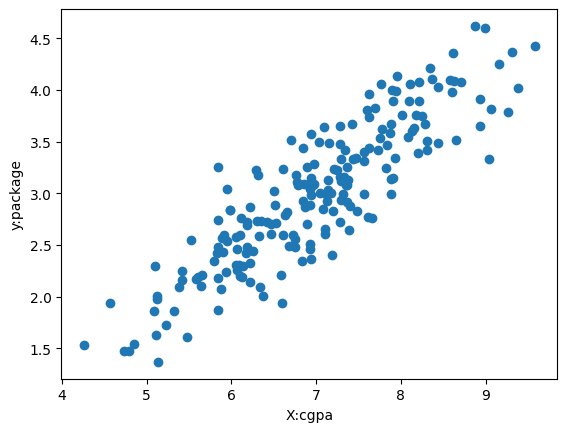

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X_train


,cgpa
105,6.66
50,9.58
9,8.31
20,7.28
148,7.57
...,...
53,6.47
142,6.93
57,6.60
177,7.09


In [ ]:
y_train


,package
105,2.82
50,4.43
9,3.51
20,3.16
148,3.40
...,...
53,2.61
142,3.04
57,1.94
177,3.64


In [ ]:
#from sklearn.linear_model import LogisticRegression
#model = LogisticRegression()
#model.fit(X_train,y_train)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
model.predict(X_test)
y_pred = model.predict(X_test)
y_pred


array([2.0115599 , 2.35690053, 3.73826305, 2.93435535, 3.63635926,
       2.5040949 , 2.39652978, 3.1268403 , 3.3872611 , 2.09647973,
       2.7135638 , 2.64562794, 3.78921495, 1.95494668, 2.48144961,
       2.11912501, 1.94928536, 3.11551765, 2.49843357, 4.17984615,
       2.57203076, 3.09287236, 3.40424506, 3.27969598, 2.83245156,
       2.92869403, 2.57203076, 2.5040949 , 3.52313282, 2.24367409,
       2.55504679, 1.93796272, 2.92869403, 1.72849381, 2.94001668,
       3.0758884 , 2.25499674, 3.44387432, 4.16852351, 2.55504679])

In [ ]:
X_test.iloc[0].values

array([5.23])

In [ ]:
y_test.iloc[0]

np.float64(1.73)

In [ ]:
X_test.head(),y_test.head() #cgpa

(     cgpa
 120  5.23
 114  5.84
 149  8.28
 54   6.86
 31   8.10,
 120    1.73
 114    1.87
 149    3.67
 54     3.09
 31     3.89
 Name: package, dtype: float64)

In [ ]:
y_pred #package

array([2.0115599 , 2.35690053, 3.73826305, 2.93435535, 3.63635926,
       2.5040949 , 2.39652978, 3.1268403 , 3.3872611 , 2.09647973,
       2.7135638 , 2.64562794, 3.78921495, 1.95494668, 2.48144961,
       2.11912501, 1.94928536, 3.11551765, 2.49843357, 4.17984615,
       2.57203076, 3.09287236, 3.40424506, 3.27969598, 2.83245156,
       2.92869403, 2.57203076, 2.5040949 , 3.52313282, 2.24367409,
       2.55504679, 1.93796272, 2.92869403, 1.72849381, 2.94001668,
       3.0758884 , 2.25499674, 3.44387432, 4.16852351, 2.55504679])

In [ ]:
X_test.iloc[0],y_test.iloc[0],y_pred[0]


(cgpa    5.23
 Name: 120, dtype: float64,
 np.float64(1.73),
 np.float64(2.01155989947304))

In [ ]:
print(pd.DataFrame({'CGPA':X_test.values.reshape(-1),'Actual_Package:':y_test,'Predicted_Package:':y_pred}))
#X_test.values.reshape(-1)

     CGPA  Actual_Package:  Predicted_Package:
120  5.23             1.73            2.011560
114  5.84             1.87            2.356901
149  8.28             3.67            3.738263
54   6.86             3.09            2.934355
31   8.10             3.89            3.636359
81   6.10             2.20            2.504095
126  5.91             2.60            2.396530
134  7.20             2.83            3.126840
43   7.66             2.76            3.387261
17   5.38             2.09            2.096480
157  6.47             2.70            2.713564
33   6.35             2.73            2.645628
52   8.37             4.11            3.789215
102  5.13             1.37            1.954947
124  6.06             2.31            2.481450
27   5.42             2.16            2.119125
1    5.12             1.98            1.949285
79   7.18             3.00            3.115518
8    6.09             2.31            2.498434
164  9.06             3.82            4.179846
170  6.22    

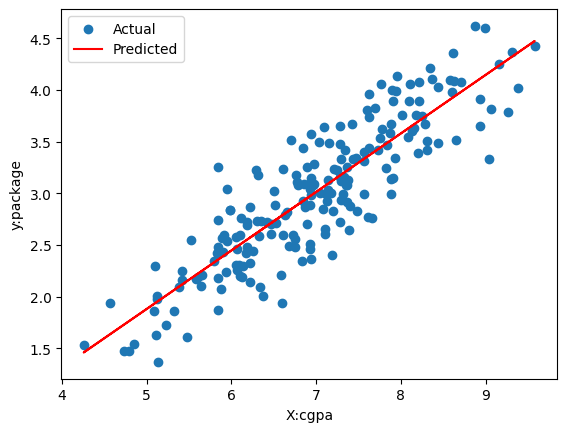

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.plot(X,model.predict(X),color = 'red')
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.legend(['Actual','Predicted'])
plt.show()



In [ ]:
model.coef_

array([0.56613218])

In [ ]:
model.intercept_

np.float64(-0.9493114059881869)